In [22]:
%load_ext autoreload
%autoreload 2

# 2 Angle Classifier

This notebook should be run after having completed the `1 - usability tagger.ipynb` notebook and the `apply_bintag.ipynb` notebook. These two notebooks are responsible for cleaning up the dataset and help to avoid letting the models learn on images of interior elements, car accesoires, odometers, placeholder images etc...

The goal of this notebook is to predict the angle at which an image is taken and see if this is usefull to finetune models on. The reasoning behind this are visual cues often shared among different models of the same brand: 

e.g. BMW has a few distinctive visual cues in their design language of cars: 
- Frontside: Kidney grill - an element that has been introduced on the BMW 303 in 1933 and has known various redesigns (https://www.bmw.com/en/design/the-bmw-kidney-grille-through-time.html).
- Sideview: Hoffmeister kink - A subtle curve in the C-pillar (not exclusively but predominantly used by BMW: https://en.wikipedia.org/wiki/Hofmeister_kink )

e.g. Volvo:
- Frontside: Thor's hammer headlights: Used in modern cars the DRL's are inspired by Swede's folklore and dubbed the "Thor's Hammer Headlights" (https://www.matthewsvolvosite.com/thors-hammer-headlights/) 

... 

The aim of this notebook is to provide an estimate of the angle at which a picture is taken. In the next phase (Brand Prediction) We'll compare if training models on specific angles are more precise than models trained on all angles at once. The idea is that a model will pick up these visual cues by focussing on only a specific angle more effectively than seeing the whole dataset (this is to be investigated)

Codewise this notebook will focus on implementing new elements that might be needed later: 
1) Out of Core learning: using some kind of batch processing of the image data (Hard requirement for processing 4million images at the brand identification stage)
2) Data augmentation: adding a few functions to add more variance in the data (Hard requirement for predicting low-occuring models e.g. Ford Anglia...)

In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import OrdinalEncoder
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import sys
import re
import random
import uuid
from tqdm import tqdm


sys.path.append('../../utils')
import config_handling as conf
#from database import Database
from file_io import make_absolute_path
import implot
import cnn_helpers

2025-02-28 17:31:50.849860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#TODO: this is a better way of handling the db and basedir from conf than in phase one, apply it in other places too.
basedir, db  = conf.applyconf('../../config/automotive.conf.ini')

Connection established


## 2.1 Constants:

In [3]:
#In phase 1 we decided to have a cutoff point at 0.9pct. Put it here as a constant
BIN_TRESHOLD = 0.9
#For each tag, how many instances will we shown as part of the training data (AFTER SPLITTING)
INSTANCES = 2500
#Put the angles in order: nicer to work with later on in CM it is structured logically: 
ANGLES = ["front", "frontleft", "left", "rearleft", "rear", "rearright", "right", "frontright"]
#Random state to be used in this notebook: (not used in augmentation process - doesn't matter)
RS = 42

## 2.2 Getting tagged data for training purposes:

In [4]:
get_traindata_query = """
    SELECT * 
    FROM angletags
    JOIN images ON images.id = angletags.image_id
    WHERE angletags.angle <> 'crappy'
    """
traindata = db.execute_query(get_traindata_query)
traindf = pd.DataFrame(traindata)
traindf = make_absolute_path(traindf, basedir, 'image_path', 'abs_path', True)
traindf.sample(10)

,image_id,angle,manual_annotation,pk,id,listing_id,processed,use_image,certainty_of_outside_yolo,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,area,confidence,abs_path
2943,1278517,frontright,1,7807,1278517,82215,1,1,None,11.0,109.0,720.0,549.0,0.739731,0.830430,/home/frederic/Documents/automotive_image_data...
5466,1435607,frontleft,1,14685,1435607,92971,1,1,None,9.0,53.0,704.0,498.0,0.770720,0.753761,/home/frederic/Documents/automotive_image_data...
5113,277346,rearleft,1,13786,277346,17452,1,0,None,NaN,NaN,NaN,NaN,NaN,NaN,/home/frederic/Documents/automotive_image_data...
6284,967607,right,1,16935,967607,62829,1,1,None,1.0,30.0,750.0,448.0,0.743066,0.889648,/home/frederic/Documents/automotive_image_data...
1290,265700,right,1,3298,265700,16972,1,1,None,35.0,206.0,700.0,420.0,0.337163,0.882147,/home/frederic/Documents/automotive_image_data...
1355,661391,front,1,3465,661391,42235,1,1,None,204.0,156.0,601.0,491.0,0.316008,0.932185,/home/frederic/Documents/automotive_image_data...
5724,1049269,front,1,15335,1049269,67634,1,1,None,63.0,17.0,635.0,550.0,0.785761,0.505294,/home/frederic/Documents/automotive_image_data...
4832,1480572,rear,1,12979,1480572,95934,1,1,None,37.0,169.0,396.0,420.0,0.377671,0.794571,/home/frederic/Documents/automotive_image_data...
5528,1130857,rear,1,14840,1130857,72944,1,1,None,193.0,135.0,559.0,451.0,0.308061,0.723173,/home/frederic/Documents/automotive_image_data...
3388,889344,rearright,1,8971,889344,57187,1,1,None,28.0,94.0,716.0,545.0,0.735746,0.850868,/home/frederic/Documents/automotive_image_data...


In [5]:
traindf.angle.value_counts()

angle
frontleft     1491
frontright    1127
rearright     1058
rearleft      1014
front          906
rear           788
right          493
left           484
Name: count, dtype: int64

There's some class imbalance here (frontleft is over 3 times more prevalent than shots taken from the left). We'll use oversampling techniques on all classes to show the model `INSTANCES` amount of instances per class. In an attempt to improve generalization we'll add small image manipulation methods to an image that is not shown for the first time (e.g. gaussian noice, warping, stretching....) WE DO NOT FLIP OR MIRROR the image, this would mean a different antletag would be needed. (You could for instance flip an image LEFT to RIGHT and then use the other tag, but we'll not be doing this!)

Before augmenting, we need to apply a solid splitting strategy to avoid feature leaking: 

## 2.3 Train test split.
Use a stratified split based on the angle to use 20% of the data as unseen testdata. This is done based on the *angle* label.

In [6]:
X_train, X_test = train_test_split(traindf, test_size=0.2, random_state=RS, stratify=traindf.angle)


In [7]:
assert (len(traindf) == len(X_train) + len(X_test))

`X_test` are not touched for learning; we stash them away and look back to them after training a CNN. NO augmentation will be done on X_test. Notice that we do not have our targets yet. It's a bit easier to work with like this untill I have my classes balanced out using augmentation.

## 2.4 Applying data augmentation and getting balanced classes: 
I'm limited with memory and don't want to have the augmented images in memory. In stead I'll use the SSD (M2 drive - so fast IO) to store these augmented pictures. (Sacrifice some storage, to gain free memory). The overhead is the IO speed of the M2 SSD vs IO speed of RAM - which is a significant penalty, but I can live with this. 

Augmented images will be stored using a UUIDV4 (almost guaranteed to be unique: see pigeonhole principle) so I'm not worried about overwriting data. augmented images will find a nice welcoming home in a dedicated folder that I can send to oblivition after the notebook is done - these are not needed further down the lifecyle of this project.

The content of the `X_test` dataframe will not be augmented, the `X_train` dataframe will be augmented so that all classes are equally present. This will be stored in a new dataframe at the end of section 2.4

In [8]:
#otherwise tf keeps complaining when adding gaussian noise
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-02-28 17:31:54.152257: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-02-28 17:31:56.787428: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-02-28 17:31:56.787514: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [9]:
def augment(sampled_df): 
    row = sampled_df.iloc[0].copy()
    impath = row['abs_path']
    uuid_v4 = str(uuid.uuid4())
    new_name = uuid_v4 + '.' + impath.split('.')[-1]
    coords = (row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y'])
    image = cv2.imread(impath)
    augmented_path = os.path.join(basedir, 'augmentated data', 'angle phase', new_name)
    os.makedirs(os.path.dirname(augmented_path), exist_ok=True)

    base_action = random.randint(0,100)
    #80% of images has only ONE mutation
    #15% has TWO mutations
    # 5% of images has THREE mutatations applied. 
    mutation_options = [0, 1, 2]
    if base_action < 85: 
        mutations = random.sample(mutation_options, 1)         #pick ONE mutation
    elif base_action < 95: 
        mutations = random.sample(mutation_options, 2)         #pick TWO mutations
    else:
        mutations = random.sample(mutation_options, len(mutation_options))              #Perform ALL THREE mutations in random order.
    modded_img = image.copy()
    for mutation in mutations: 
        if mutation == 0: 
            modded_img = cnn_helpers.augm_channel_shuffle(modded_img)
        elif mutation == 1:
            sigma = random.randint(40, 80)
            modded_img = cnn_helpers.augm_add_random_noise(modded_img, 0, sigma)
        else:
            stretch = random.uniform(0.8, 1.3)
            modded_img, coords = cnn_helpers.augm_stretch_image_and_bbox(modded_img, coords, stretch)
    #print(type(modded_img))
    #print(modded_img.shape())
    cv2.imwrite(augmented_path, modded_img)
    row['abs_path'] = augmented_path
    row['yolobox_top_left_x'] = coords[0]
    row['yolobox_top_left_y'] = coords[1]
    row['yolobox_bottom_right_x'] = coords[2]
    row['yolobox_bottom_right_y'] = coords[3]
    return row    

In [10]:
new_rows = []
for angle in X_train.angle.unique():
    relevant_angles = X_train.query(f'angle=="{angle}"')
    amount_to_augment = INSTANCES - len(relevant_angles)
    for _ in tqdm(range(amount_to_augment)):
        base_image = relevant_angles.sample(1)
        augmented = augment(base_image)
        new_rows.append(augmented)
        

100%|██████████| 1598/1598 [00:20<00:00, 77.19it/s] 


In [11]:
augmented_df = pd.concat([X_train, pd.DataFrame(new_rows)], axis=0)
augmented_df = augmented_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [12]:
#finally prepare the augmented_df by cating the bbox fields to int and setting nan to sentinel -1
augmented_df = cnn_helpers.cast_bbox_values(augmented_df)

/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../utils/cnn_helpers.py:145: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(-1)


In [13]:
augmented_df.angle.value_counts()
#augmentation was good.

angle
rearright     2500
rearleft      2500
rear          2500
frontleft     2500
frontright    2500
left          2500
right         2500
front         2500
Name: count, dtype: int64

## 2.5 Assigning Train/test variables
I kept my labels part of the dataframe during the data augmentation phase, with that out of hte way, time to go back to standard practice. We'll not be using `train_test_split()` method here as we already have this split done. 

In [14]:
y_train = augmented_df['angle']
X_train = augmented_df.drop(columns=['angle'])
y_test = X_test['angle']
X_test = X_test.drop(columns=['angle'])

## 2.6 Label encoding.
We need to convert the `ANGLES` cosntant to  integer labels. Originally this notebook used `LabelEncoder`, however this does not preserve the order we have in `ANGLES`. This order does make it easier to interpret the confusionmatrix at the end. To overcome this nuissance we use `ordinalencoder`. More info on this issue: https://github.com/scikit-learn/scikit-learn/issues/12086 

In [15]:
angles_nested = [[angle] for angle in ANGLES]
ordinal_encoder = OrdinalEncoder(categories=[ANGLES])
ordinal_encoder.fit(angles_nested)
y_train_encoded = ordinal_encoder.transform([[label] for label in y_train]).flatten().astype('int')
y_test_encoded = ordinal_encoder.transform([[label] for label in y_test]).flatten().astype('int')

## 2.7 Training a CNN
In phase one epochs weren't implemented in an optimal way, apparently you can mid-epoch decide to dump and store the result. Python can also self-monitor how much improvement is made per epoch. So it can early stop. These techniques are part of callbacks API (earlystopping and ModelCheckpoint)
https://machinelearningmastery.com/check-point-deep-learning-models-keras/

These techniques will be used in phase 2

In [16]:
#how large will the image be to train on: If you change it here, whole script is updated
shape = 256

#Use or Not use BBOX? In phase 1 it wasn't worth the effort, what about angle tagging?? 
# I expect it to be useful here as cutting an image of does not make i harder to identify
# and a cut off image does not render it 'invalid' for this task.
bboxs = [True, False]

#At how many epoch(stps) should a dump of the model be made (Checkpoints)
epoch_checkpoint = 5 
#What's the maximum amount of epochs to go over before killing the learing process.
max_epoch = 100

#Batch size
batch_size = 32

#number of classes: 
numclasses = len(ANGLES)

#For online learning we presplit our X_train in a new train and validation set, define ratio here: 
validation_split = 0.2

#where to save (checkpoint iterations of ) the model?
model_dest_dir = os.path.join(os.getcwd(), '..', '..', 'models', 'angle_models')
os.makedirs(model_dest_dir, exist_ok=True)


In [17]:
#Note: I'm comfortable with this way of splitting, remember that the datframe
# was shuffled at random and that X_train was a perfectly even distributed class.
# Yes, there will be some inequality, but this is not of any significance. 
train_data = X_train[:int(1-validation_split * len(X_train))]
val_data = X_train[int(1-validation_split * len(X_train)):]
y_train_data = y_train_encoded[:int(1-validation_split * len(X_train))]
y_val_data = y_train_encoded[int(1-validation_split * len(X_train)):]

assert(len(train_data)+ len(val_data) == len(X_train))
assert(len(y_train_data) ==  len(train_data))

for bbox in bboxs:
    #TODO: figure out a way to NOT require preloading X_Train_imgs (we need this anyway for a later phase, might as well start here)
    #X_train_imgs = []
    #for _, row in X_train.iterrows():
    #    coords = [row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y']]
    #    X_train_imgs.append(cnn_helpers.preprocess_image(row['abs_path'], bbox, coords, shape))
    #Do this later to save memory.
    #X_test_imgs = []
    #for _, row in X_test.iterrows():
    #    X_test_imgs.append(cnn_helpers.preprocess_image(row['abs_path'], False, [0,0,0,0], shape))
    #X_train_imgs = np.array(X_train_imgs)
    ############
    # Deep learning part here: implement the plateau and early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=6, 
        restore_best_weights=True
    )
    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        min_lr=1e-6, 
        verbose=1
    )
    # Save an the model every xth (epoch_checkpoint) epoch:

        #filepath=lambda epoch, logs: os.path.join(
        #    model_dest_dir, 
        #    f'model_angles-bbox={bbox}-epoch={epoch:02d}.keras'
        #),

    e = '{epoch:02d}'
    model_checkpoint = ModelCheckpoint(
        filepath=os.path.join(model_dest_dir, f'model_angles-bbox={bbox}-epoch={e}.keras'),
        save_freq=epoch_checkpoint,
        save_best_only=False,
        verbose=0
    )


    # Angle classifier with CNN
    angle_model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(shape, shape, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(ANGLES), activation='softmax')
    ])
    angle_model.compile(
        optimizer=Adam(learning_rate=0.001), 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    #Do just in time preprocessing of the images: yields both the numpy array and targets!
    train_gen = cnn_helpers.image_generator(
        batch_size=batch_size, 
        data_frame=train_data, 
        bboxs=bboxs, 
        shape=shape, 
        y_train_encoded=y_train_data
    )
    #Split validation separately
    val_gen = cnn_helpers.image_generator(
        batch_size=batch_size, 
        data_frame=val_data, 
        bboxs=bboxs, 
        shape=shape, 
        y_train_encoded=y_val_data
    )

    angle_model.fit(
        train_gen,
        epochs=max_epoch, 
        steps_per_epoch=len(train_data) // batch_size,
        batch_size=batch_size, 
        validation_data=val_gen,
        validation_steps = len(val_data) // batch_size,
        callbacks=[early_stopping, lr_scheduler, model_checkpoint] 
    )

#Okay, the callback principle is really cool.
# You just put a bunch of assigned variables in there that are mapped to some part of the KERAS API and it automagically handles everything for you. 


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-02-28 17:34:56.956082: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-02-28 17:34:56.956211: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-02-28 17:34:56.956261: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but ther

Epoch 1/100


I0000 00:00:1740760498.843663    6346 service.cc:146] XLA service 0x7a3c80007b80 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1740760498.843706    6346 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 6700 XT, AMDGPU ISA version: gfx1030
2025-02-28 17:34:58.879729: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  1/500 ━━━━━━━━━━━━━━━━━━━━ 2:10:03 16s/step - accuracy: 0.2500 - loss: 2.0508

I0000 00:00:1740760513.619619    6346 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 173s 316ms/step - accuracy: 0.7029 - loss: 1.3432 - val_accuracy: 0.9498 - val_loss: 0.1634 - learning_rate: 0.0010
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 324ms/step - accuracy: 0.9587 - loss: 0.1353 - val_accuracy: 0.9824 - val_loss: 0.0717 - learning_rate: 0.0010
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 335ms/step - accuracy: 0.9796 - loss: 0.0733 - val_accuracy: 0.9882 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 169s 337ms/step - accuracy: 0.9851 - loss: 0.0488 - val_accuracy: 0.9934 - val_loss: 0.0288 - learning_rate: 0.0010
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 169s 339ms/step - accuracy: 0.9904 - loss: 0.0356 - val_accuracy: 0.9869 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 170s 341ms/step - accuracy: 0.9904 - loss: 0.0320 - val_accuracy: 0.9929 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 172s 344ms/step - accuracy: 0

In [18]:
#finished training the two models they're dumped already. Let's see how these performed. 

## 2.7 Asserting model performance

Let's process the original testdata of images for each of the eight angles; this batch is small enough to fit in memory, so we run it in a single go. For this we'll be revisiting the variables `X_test` and `y_test` created in step 2.3. 

We have two variants on the same model: one with and one without BoundingBox. The images need to be preprocessed in the same way to assess performance. 

Just out of interest we'll also use non-bound images on the bounded model and vice versa; in total we'll be generating four confusion matrices: 

1) Model With BBOX + Images with BBOX
2) Model without BBOX + Images without BBOX
3) Model With BBOX * Images without BBOX
4) Model without BBOX + Images with BBOX

The two final models are simply the models with the highest Epoch count; one with BBOX to true in the filename and one without. Since epochs are time-sensitively created (epoch 2 is created later than epoch 1); we can simply take the 'most recent created file' for BBOX TRUE and for BBOX FALSE, those are automatically the best models. 

In [19]:
models = os.listdir(model_dest_dir)
model_paths = [os.path.join(model_dest_dir, f) for f in models if os.path.isfile(os.path.join(model_dest_dir, f))]
sorted_models = sorted(model_paths, key=os.path.getctime)


In [20]:
sorted_models

['/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../models/angle_models/model_angles-bbox=True-epoch=13.keras',
 '/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../models/angle_models/model_angles-bbox=True-epoch=14.keras',
 '/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../models/angle_models/model_angles-bbox=True-epoch=15.keras',
 '/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../models/angle_models/model_angles-bbox=False-epoch=16.keras',
 '/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../models/angle_models/model_angles-bbox=False-epoch=17.keras',
 '/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../models/angle_models/model_angles-bbox=False-epoch=18.keras',
 '/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../models/angle_m

/home/frederic/Documents/automotive_project/notebooks/machine learning notebooks/../../utils/cnn_helpers.py:145: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(-1)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


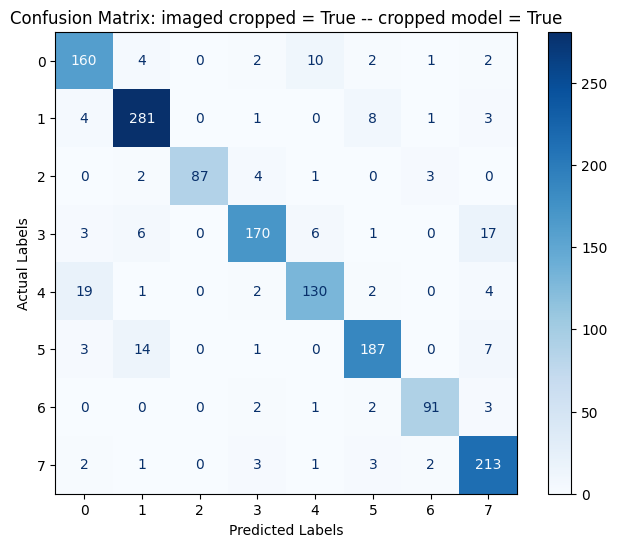

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


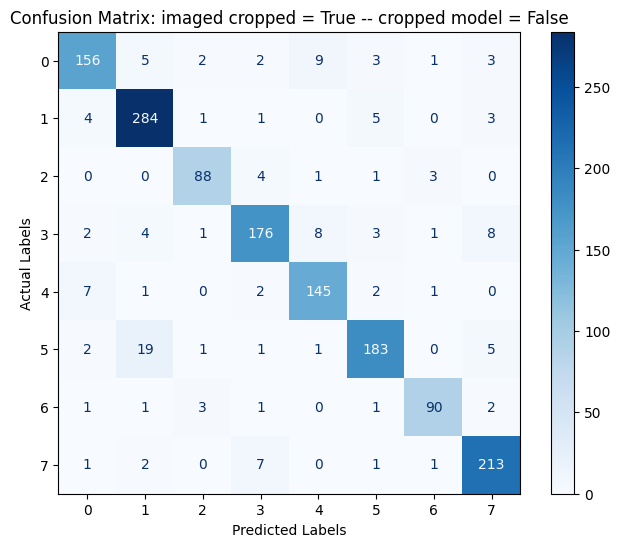

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


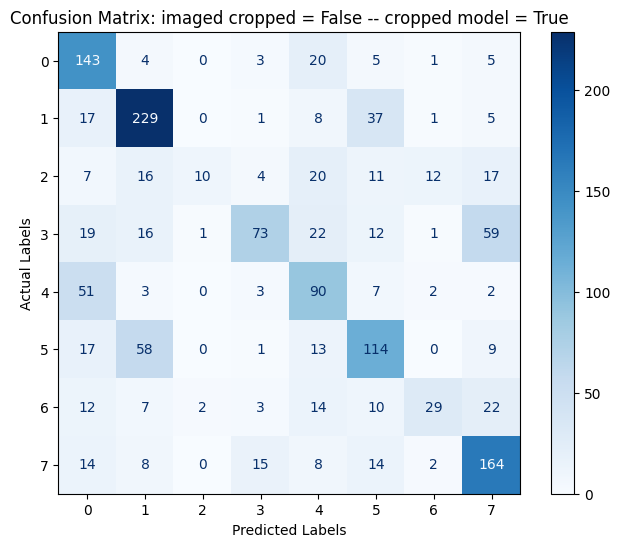

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


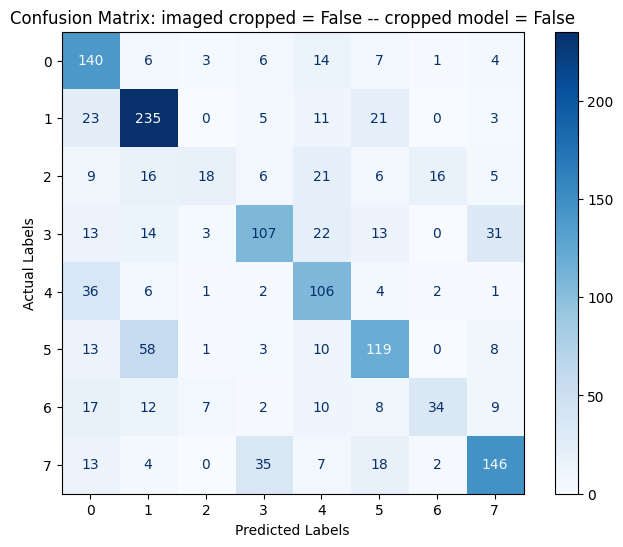

In [21]:
X_test = cnn_helpers.cast_bbox_values(X_test)
#decoded_labels = label_encoder.inverse_transform(range(8))
for crop_image in bboxs:
    X_test_images = []
    for idx, row in X_test.iterrows():
        coords = [row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y']]
        image = cnn_helpers.preprocess_image(row['abs_path'], crop_image, coords, shape)
        X_test_images.append(image)
    X_test_images = np.array(X_test_images)
    for use_cropped_model in bboxs:
        matching_models = [f for f in sorted_models if f'bbox={use_cropped_model}-' in f]
        model = load_model(matching_models[-1])
        predicts = model.predict(X_test_images)
        predicts = np.argmax(predicts, axis=1)
        confusion_on_y_test = pd.DataFrame(
            {
                'actuals': y_test_encoded,
                'predicts': predicts
            }
        )

        #confusion_on_y_test.sample(5)
        cm = confusion_matrix(confusion_on_y_test['actuals'], confusion_on_y_test['predicts'], labels=range(8))

        # Display confusion matrix using matplotlib
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=True)

        plt.title(f"Confusion Matrix: imaged cropped = {crop_image} -- cropped model = {use_cropped_model}")
        plt.xlabel("Predicted Labels")
        plt.ylabel("Actual Labels")
        plt.show()
